# Results Aggregation & Visualization

**CS 1675 - Introduction to Machine Learning**

---

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# Color scheme - clean, professional
COLORS = ['#2C3E50', '#E74C3C', '#18BC9C']  # Charcoal, Coral red, Teal
MODELS = ['Logistic Regression', 'Random Forest', 'Neural Network']

print("Libraries loaded")

Libraries loaded


## 1. Baseline Performance

Performance metrics for all 3 models trained on the full feature set.

In [43]:
# Load baseline performance
performance = pd.read_csv('results/baseline/performance.csv', index_col=0)
performance

,Accuracy,Precision,Recall,F1,FPR,ROC-AUC
Logistic Regression,0.733835,0.343667,0.760236,0.473353,0.271094,0.820937
Random Forest,0.778399,0.381479,0.657287,0.482767,0.198987,0.816597
Neural Network,0.735452,0.346516,0.769166,0.477785,0.270843,0.826258


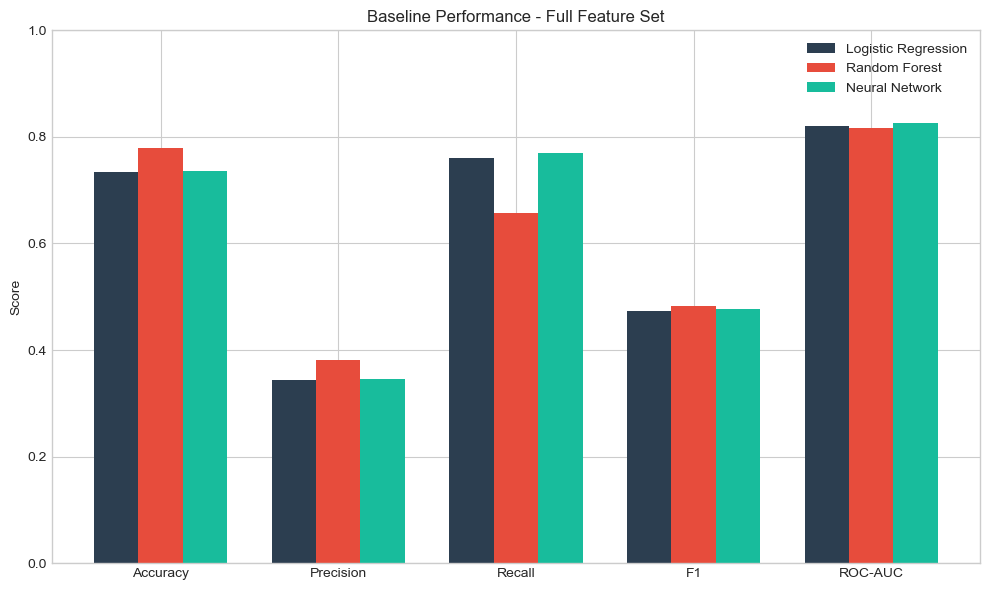

In [44]:
# Bar chart of key metrics by model
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(MODELS):
    values = performance.loc[model, metrics]
    ax.bar(x + i*width, values, width, label=model, color=COLORS[i])

ax.set_ylabel('Score')
ax.set_title('Baseline Performance - Full Feature Set')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 2. Baseline Fairness

How fair is each model across demographic groups (Race, Sex, Age)?

In [45]:
# Load baseline fairness data
def load_fairness(demo, model_short):
    df = pd.read_csv(f'results/baseline/fairness_{demo}_{model_short}.csv', index_col=0)
    return df

# Compute disparity gaps for each model and demographic
def get_gaps(demo, model_short):
    df = load_fairness(demo, model_short)
    return {
        'Recall Gap': df['Recall'].max() - df['Recall'].min(),
        'FPR Gap': df['FPR'].max() - df['FPR'].min(),
        'Precision Gap': df['Precision'].max() - df['Precision'].min()
    }

# Build summary table
rows = []
for demo in ['race', 'sex', 'age']:
    for model_short, model_name in [('LR', 'Logistic Regression'), ('RF', 'Random Forest'), ('NN', 'Neural Network')]:
        gaps = get_gaps(demo, model_short)
        gaps['Demographic'] = demo.capitalize()
        gaps['Model'] = model_name
        rows.append(gaps)

fairness_summary = pd.DataFrame(rows)
fairness_summary

,Recall Gap,FPR Gap,Precision Gap,Demographic,Model
0,0.256113,0.225871,0.140533,Race,Logistic Regression
1,0.329472,0.196231,0.195613,Race,Random Forest
2,0.204709,0.271797,0.202105,Race,Neural Network
3,0.019696,0.050960,0.005397,Sex,Logistic Regression
4,0.003734,0.026574,0.000455,Sex,Random Forest
5,0.010492,0.053840,0.010594,Sex,Neural Network
6,0.653711,0.621876,0.213787,Age,Logistic Regression
7,0.765799,0.398107,1.000000,Age,Random Forest
8,0.709483,0.518373,0.068877,Age,Neural Network


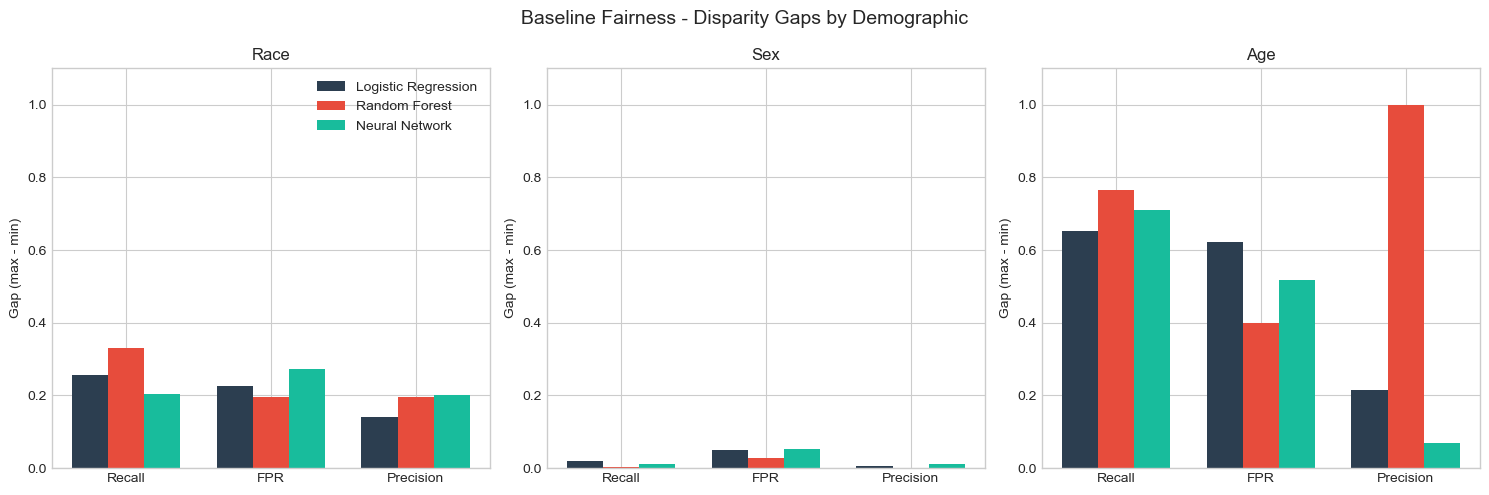

In [46]:
# Disparity gaps by demographic group - all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, demo in zip(axes, ['Race', 'Sex', 'Age']):
    demo_data = fairness_summary[fairness_summary['Demographic'] == demo]
    
    x = np.arange(3)  # 3 gap metrics
    width = 0.25
    
    for i, model in enumerate(MODELS):
        model_row = demo_data[demo_data['Model'] == model].iloc[0]
        values = [model_row['Recall Gap'], model_row['FPR Gap'], model_row['Precision Gap']]
        ax.bar(x + i*width, values, width, label=model, color=COLORS[i])
    
    ax.set_title(f'{demo}')
    ax.set_xticks(x + width)
    ax.set_xticklabels(['Recall', 'FPR', 'Precision'])
    ax.set_ylabel('Gap (max - min)')
    ax.set_ylim(0, 1.1)
    if demo == 'Race':
        ax.legend()

plt.suptitle('Baseline Fairness - Disparity Gaps by Demographic', fontsize=14)
plt.tight_layout()
plt.show()